# Heart Disease Prediction — Model Training (XGBoost)

Training and tuning an XGBoost classifier, then evaluating it on the held-out test set.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

X_train.shape, X_test.shape

((736, 21), (184, 21))

## 1. Baseline — cross-validation

5-fold stratified cross-validation on the training set with default hyperparameters, as a reference before tuning.

In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

baseline_model = XGBClassifier(random_state=42, eval_metric='logloss')
baseline_scores = cross_validate(baseline_model, X_train, y_train, cv=cv, scoring=scoring)

pd.DataFrame({
    'Metric': scoring,
    'Mean': [baseline_scores[f'test_{m}'].mean().round(3) for m in scoring],
    'Std': [baseline_scores[f'test_{m}'].std().round(3) for m in scoring],
})

,Metric,Mean,Std
0,accuracy,0.795,0.039
1,precision,0.812,0.042
2,recall,0.820,0.049
3,f1,0.815,0.036
4,roc_auc,0.869,0.036


## 2. Hyperparameter tuning

In [4]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
}

search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_dist, n_iter=50, cv=cv, scoring='f1',
    random_state=42, n_jobs=1
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV F1:", round(search.best_score_, 3))

final_model = search.best_estimator_

Best params: {'subsample': 0.7, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV F1: 0.848


## 3. Final evaluation on test set

              precision    recall  f1-score   support

     Healthy       0.87      0.79      0.83        82
     Disease       0.84      0.90      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



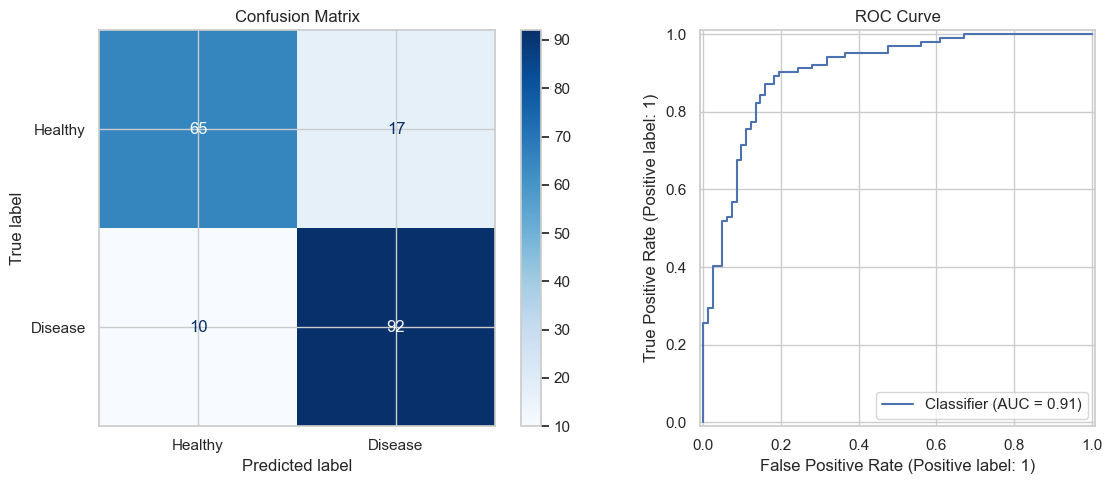

In [5]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Healthy', 'Disease']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Healthy','Disease'], cmap='Blues', ax=axes[0])
axes[0].set_title("Confusion Matrix")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("ROC Curve")
plt.tight_layout()
plt.savefig('../reports/figures/final_evaluation.png', dpi=120)
plt.show()

## 4. Feature importance (built-in)

Quick look before the dedicated SHAP notebook.

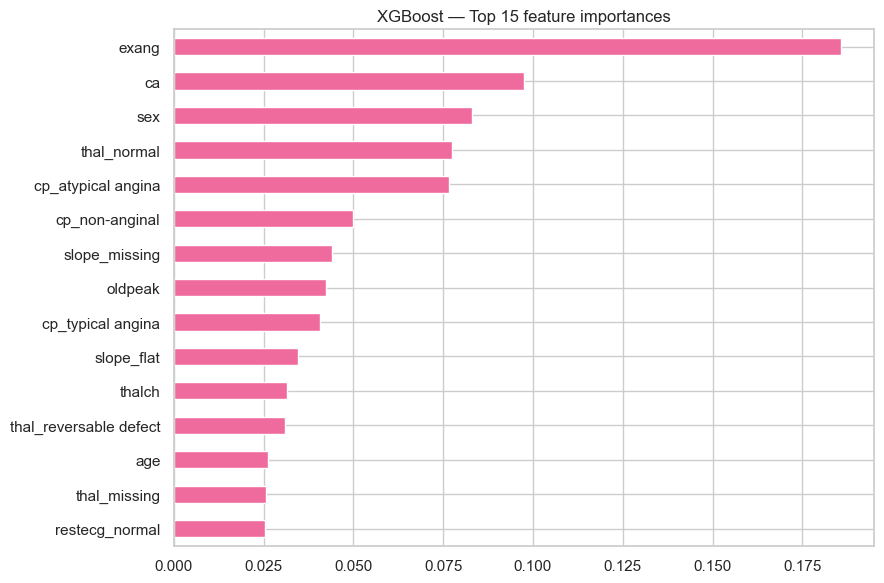

In [9]:
importances = pd.Series(final_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
importances.head(15).plot(kind='barh', color="#EF6B9E")
plt.gca().invert_yaxis()
plt.title("XGBoost — Top 15 feature importances")
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=120)
plt.show()

## 5. Save the final model

In [10]:
joblib.dump(final_model, '../models/model.pkl')
print("Model saved to models/model.pkl")

Model saved to models/model.pkl


## Summary

Baseline XGBoost (default hyperparameters, 5-fold CV): accuracy 0.795, F1 0.815, ROC-AUC 0.869.

After tuning (RandomizedSearchCV, 50 iterations, optimized for F1), the model was evaluated on the held-out test set:

- **Accuracy**: 85%
- **Confusion matrix**: 65/82 healthy correctly identified, 92/102 disease cases correctly identified
- **F1-score (Disease)**: 0.87, **Recall (Disease)**: 0.90 — the model catches most true disease cases
- **ROC-AUC**: 0.91 — strong discrimination between healthy and disease patients

Tuning improved the model over the baseline across all metrics (e.g. ROC-AUC 0.869 → 0.91).

**Top predictive features**: `exang` (exercise-induced angina) is by far the strongest predictor, followed by `ca` (number of major vessels), `sex`, `thal_normal`, and `cp_atypical angina`. This aligns with the clinical intuition from Phase 2 — these were exactly the variables that showed the clearest separation between healthy and disease patients in the exploratory analysis.

Main area for future improvement: recall on the Healthy class (0.79, 17 false positives) — the model is slightly more prone to over-predicting disease than missing it, which is an acceptable trade-off clinically but a possible next step for optimization.